# Proyecto Aplicado: Predicción No Lineal de Resolución de Quejas Financieras (CFPB)

> **Actividad 3 — Proyecto 1: Identificación del Problema**
> **Aprendizaje Máquina II — Maestría en Inteligencia Artificial**
>
> **Dataset:** Consumer Financial Protection Bureau (CFPB) — ~73,600 quejas financieras → 18 features NLP
> **Repositorio:** [GitHub — github.com/tu-usuario/am2-proyecto](https://github.com)

## Contenidos
1. [Contexto y caso de uso](#1-contexto-y-caso-de-uso)
2. [Definición del problema de ML](#2-definición-del-problema-de-ml)
3. [Obtención y exploración de datos](#3-obtención-y-exploración-de-datos)
4. [Análisis exploratorio (EDA)](#4-análisis-exploratorio-eda)
5. [Ruta de ejecución del proyecto](#5-ruta-de-ejecución-del-proyecto)
6. [Modelos candidatos y métricas](#6-modelos-candidatos-y-métricas)
7. [Viabilidad y consideraciones](#7-viabilidad-y-consideraciones)


## 1. Contexto y caso de uso

### El problema real

El **Consumer Financial Protection Bureau (CFPB)** recibe miles de quejas diarias de consumidores contra instituciones financieras estadounidenses. Cada queja incluye una narrativa en texto libre, y el proceso culmina con una **resolución**:

- **"Closed with explanation"**: la empresa responde sin compensación (~66% de los casos).
- **"Closed with monetary/non-monetary relief"**: se otorga compensación económica o ajuste (~34% de los casos).

El triaje manual de estas quejas es costoso. Automatizarlo con ML permite **priorizar casos críticos, reducir tiempos de respuesta y evitar sanciones regulatorias**.

### Pipeline de NLP previo

Las 18 features numéricas fueron generadas por un pipeline de 6 etapas desarrollado en la asignatura de Procesamiento de Lenguaje Natural:

```
Carga → Limpieza → Preprocesamiento (spaCy) → NER → Sentimiento (VADER + TextBlob) → Feature Engineering
```

Esto transforma texto libre en un problema de **clasificación tabular no lineal**.

### Justificación de no linealidad

La relación entre las features y la resolución **no es lineal**. Una queja con sentimiento muy negativo no necesariamente recibe compensación; una queja con muchos términos legales tampoco garantiza relief. Es la **interacción compleja y multidimensional** lo que determina el resultado — se requieren **métodos de kernel**.


## 2. Definición del problema de ML

| Elemento | Descripción |
|----------|-------------|
| **Tipo de problema** | Clasificación binaria supervisada con desbalance de clases |
| **Target** | `target` = 1 si "monetary relief" o "non-monetary relief"; 0 si "explanation" |
| **Features** | 18 variables numéricas NLP (longitud, diversidad léxica, términos legales, entidades, sentimiento VADER + TextBlob) |
| **Clases** | 0 = Explanation (~66%) / 1 = Relief (~34%) |
| **Métrica principal** | **F1-Score** — balance precision-recall en contexto desbalanceado |
| **Métricas complementarias** | ROC-AUC, Precision, Recall |
| **Validación** | Stratified K-Fold (k=5) |

> *"¿Se puede predecir la resolución de una queja CFPB a partir de features NLP con un F1-Score superior al baseline naïve usando métodos de kernel?"*


## 3. Obtención y exploración de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
alt.renderers.enable('default')
np.random.seed(42)
print('✓ Librerías cargadas.')


✓ Librerías cargadas.


### Carga del dataset (Parquet — 2.1 MB)

In [2]:
nlp_features = [
    'narrative_length', 'word_count', 'unique_words', 'lexical_diversity',
    'legal_term_count', 'uppercase_ratio', 'mask_count',
    'entity_count', 'org_count', 'law_count', 'money_count', 'gpe_count',
    'vader_compound', 'vader_neg', 'vader_neu', 'vader_pos',
    'textblob_polarity', 'textblob_subjectivity'
]

# Carga desde Parquet (target ya precomputado del pipeline NLP)
df_ml = pd.read_parquet('data/cfpb_features.parquet')
df_ml['diagnostico'] = df_ml['target'].map({0: 'Explanation', 1: 'Relief'})

n_total = df_ml.shape[0]
n_relief = df_ml['target'].sum()
print(f'✓ Dataset cargado: {n_total:,} registros x {df_ml.shape[1]} columnas')
print(f'  Features NLP: {len(nlp_features)}')
print(f'  Target: {n_relief:,} Relief ({n_relief/n_total:.1%}) | {n_total-n_relief:,} Explanation ({(n_total-n_relief)/n_total:.1%})')
print(f'  Tamaño en disco: 2.1 MB (Parquet comprimido)')


✓ Dataset cargado: 73,343 registros x 20 columnas
  Features NLP: 18
  Target: 24,626 Relief (33.6%) | 48,717 Explanation (66.4%)
  Tamaño en disco: 2.1 MB (Parquet comprimido)


## 4. Análisis exploratorio (EDA)

### Estadísticas descriptivas


In [3]:
length_feats = ['narrative_length', 'word_count', 'unique_words', 'lexical_diversity']
sentiment_feats = ['vader_compound', 'vader_neg', 'vader_neu', 'vader_pos',
                   'textblob_polarity', 'textblob_subjectivity']

print('--- Features de longitud ---')
print(df_ml[length_feats].describe().round(2).to_string())
print(f'\n--- Features de sentimiento ---')
print(df_ml[sentiment_feats].describe().round(2).to_string())


--- Features de longitud ---
       narrative_length  word_count  unique_words  lexical_diversity
count          73343.00    73343.00      73343.00           73343.00
mean            1017.92       86.79         47.53               0.67
std             1302.77      114.80         42.67               0.19
min               20.00        1.00          1.00               0.00
25%              343.00       27.00         20.00               0.55
50%              663.00       55.00         37.00               0.69
75%             1210.00      104.00         60.00               0.82
max            32596.00     4213.00        770.00               0.98

--- Features de sentimiento ---
       vader_compound  vader_neg  vader_neu  vader_pos  textblob_polarity  textblob_subjectivity
count        73343.00   73343.00   73343.00   73343.00           73343.00               73343.00
mean            -0.04       0.09       0.82       0.09               0.01                   0.40
std              0.68     

### Distribuciones por clase (6 features clave)

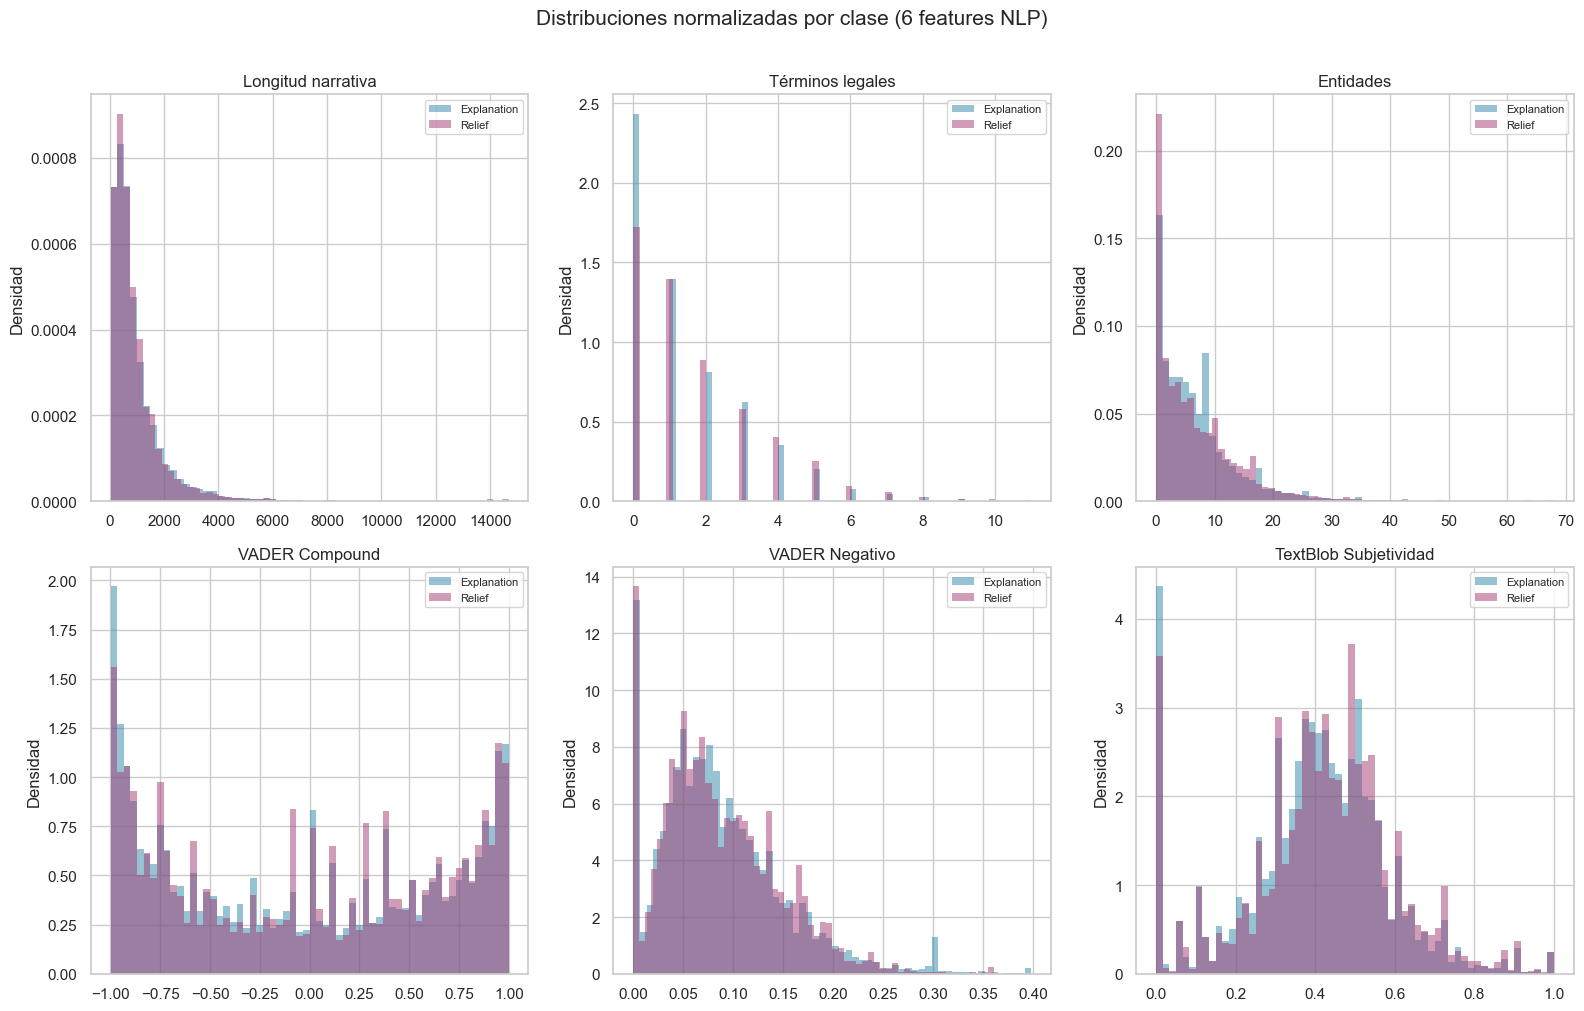

In [4]:
key_cols = ['narrative_length', 'legal_term_count', 'entity_count',
            'vader_compound', 'vader_neg', 'textblob_subjectivity']
key_labels = ['Longitud narrativa', 'Términos legales', 'Entidades',
              'VADER Compound', 'VADER Negativo', 'TextBlob Subjetividad']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = {'Explanation': '#2E86AB', 'Relief': '#A23B72'}

for idx, (col, title) in enumerate(zip(key_cols, key_labels)):
    ax = axes.ravel()[idx]
    for label in ['Explanation', 'Relief']:
        mask = df_ml['diagnostico'] == label
        data = df_ml.loc[mask, col].dropna()
        data_clipped = data.clip(lower=data.quantile(0.001), upper=data.quantile(0.999))
        ax.hist(data_clipped, bins=60, alpha=0.5, label=label, color=colors[label], density=True, edgecolor='none')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8)
    ax.set_ylabel('Densidad')

plt.suptitle('Distribuciones normalizadas por clase (6 features NLP)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


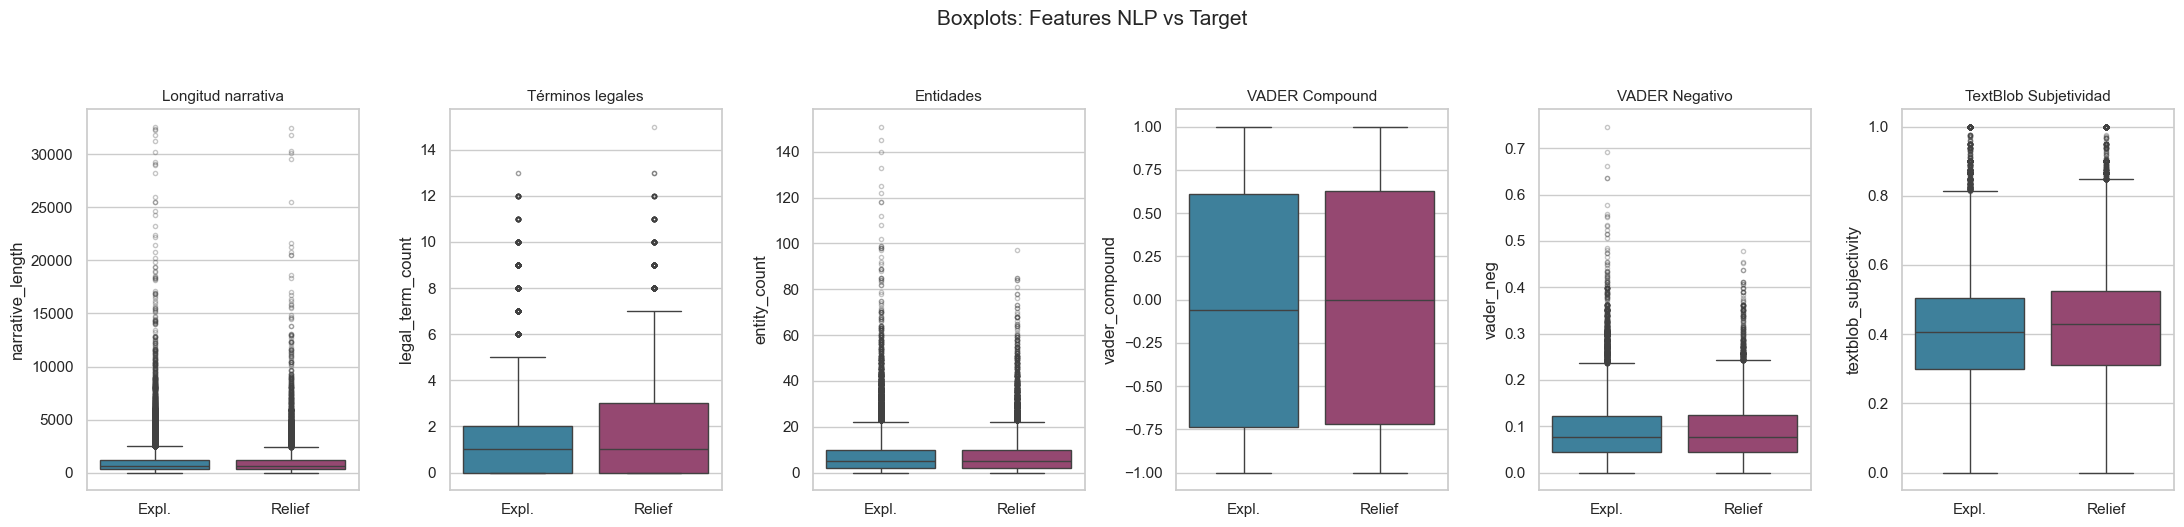

In [5]:
# Boxplots comparativos
fig, axes = plt.subplots(1, 6, figsize=(22, 5))
palette = {0: '#2E86AB', 1: '#A23B72'}

for idx, (col, title) in enumerate(zip(key_cols, key_labels)):
    sns.boxplot(data=df_ml, x='target', y=col, hue='target',
                palette=palette, legend=False, ax=axes[idx],
                flierprops=dict(marker='.', alpha=0.3))
    axes[idx].set_title(title, fontsize=11)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Expl.', 'Relief'])
    axes[idx].set_xlabel('')

plt.suptitle('Boxplots: Features NLP vs Target', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()


### Matriz de correlación

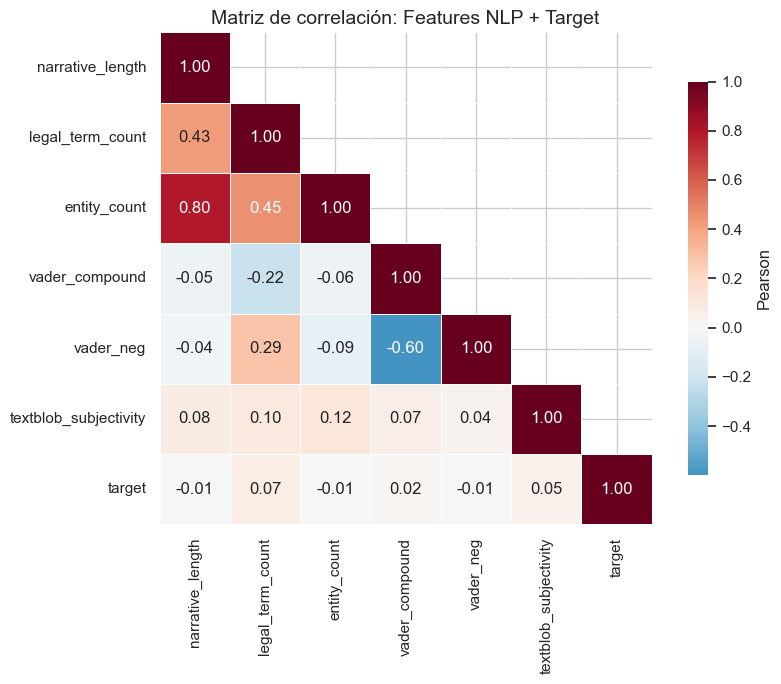


Correlación con target (relief):
legal_term_count         0.073738
textblob_subjectivity    0.051804
vader_compound           0.022591
vader_neg               -0.008323
entity_count            -0.009378
narrative_length        -0.011706


In [6]:
corr_cols = key_cols + ['target']
corr = df_ml[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson', 'shrink': 0.8})
plt.title('Matriz de correlación: Features NLP + Target', fontsize=14)
plt.tight_layout()
plt.show()

print('\nCorrelación con target (relief):')
print(corr['target'].drop('target').sort_values(ascending=False).to_string())


### Reducción de dimensionalidad: PCA

Proyectamos las 18 features NLP a 2D sobre una muestra estratificada de 10,000 registros.


In [7]:
# Submuestreo estratificado manual
sample_size = 10000
n_class_0 = (df_ml['target'] == 0).sum()
n_class_1 = (df_ml['target'] == 1).sum()
df_0 = df_ml[df_ml['target'] == 0].sample(n=min(n_class_0, sample_size // 2), random_state=42)
df_1 = df_ml[df_ml['target'] == 1].sample(n=min(n_class_1, sample_size // 2), random_state=42)
df_sample = pd.concat([df_0, df_1], ignore_index=True)

X_sample = df_sample[nlp_features].values
y_sample = df_sample['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada - PC1: {var_exp[0]:.1%} | PC2: {var_exp[1]:.1%}')
print(f'Acumulada (2 PCs): {var_exp.sum():.1%}')
print(f'Muestra PCA: {X_sample.shape[0]:,} registros')


Varianza explicada - PC1: 31.4% | PC2: 14.5%
Acumulada (2 PCs): 45.8%
Muestra PCA: 10,000 registros


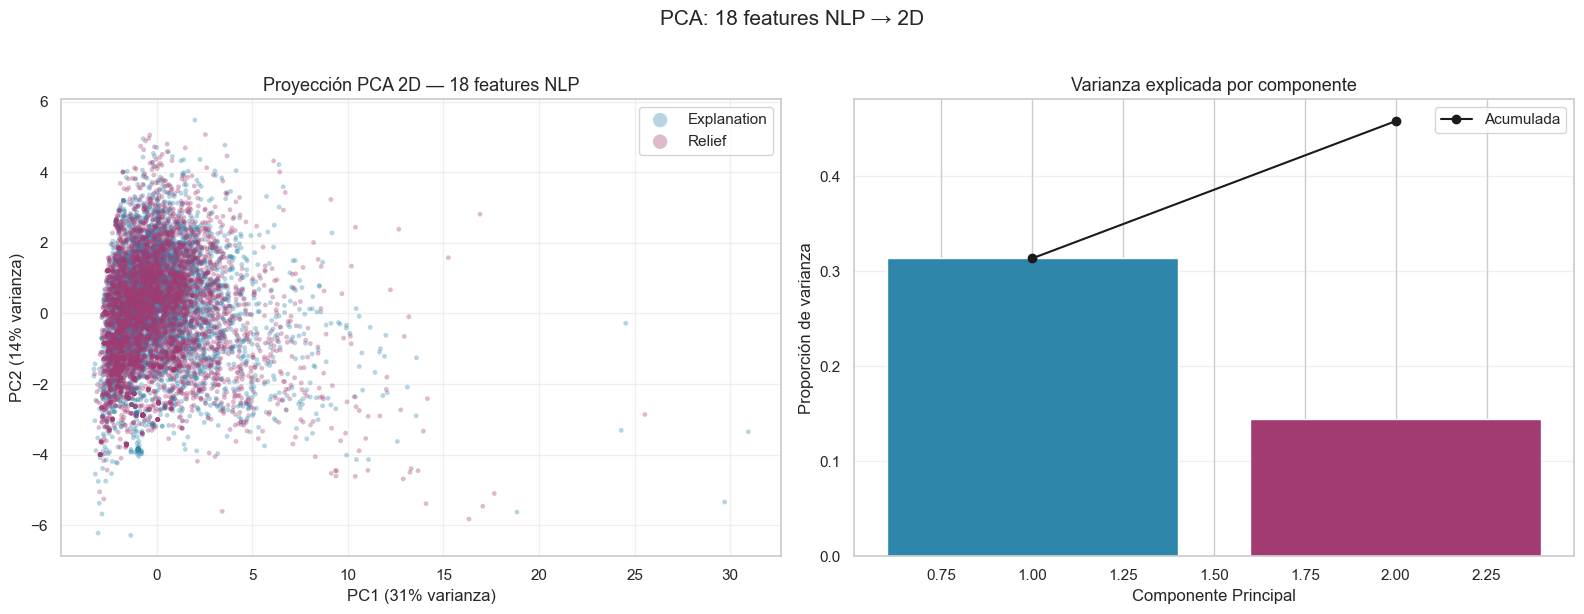

In [8]:
# Panel: PCA scatter + Varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cpal = ['#2E86AB', '#A23B72']
lpal = ['Explanation', 'Relief']

for tval, col, lab in zip([0, 1], cpal, lpal):
    mask = y_sample == tval
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=col, label=lab, alpha=0.35, s=12, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.0%} varianza)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.0%} varianza)')
axes[0].set_title('Proyección PCA 2D — 18 features NLP', fontsize=13)
axes[0].legend(markerscale=3)
axes[0].grid(True, alpha=0.3)

var_all = pca.explained_variance_ratio_
axes[1].bar(range(1, len(var_all)+1), var_all, color=['#2E86AB','#A23B72']+['#ccc']*(len(var_all)-2), edgecolor='white')
axes[1].plot(range(1, len(var_all)+1), np.cumsum(var_all), 'ko-', ms=6, label='Acumulada')
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('Proporción de varianza')
axes[1].set_title('Varianza explicada por componente', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('PCA: 18 features NLP → 2D', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


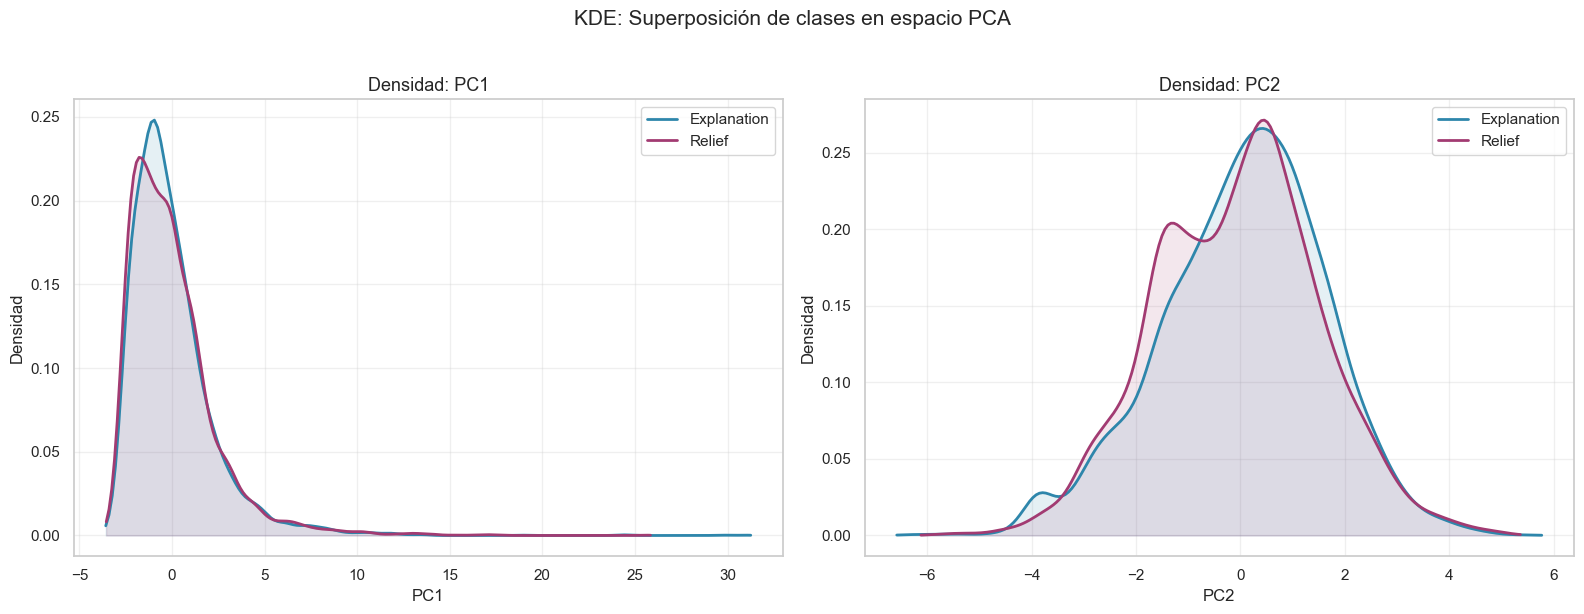

In [9]:
# KDE: Superposición de clases
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = y_sample

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    for tval, col, lab in zip([0, 1], cpal, lpal):
        d = df_pca.loc[df_pca['target'] == tval, pc].values
        kde = gaussian_kde(d)
        xg = np.linspace(d.min()-0.3, d.max()+0.3, 200)
        ax.plot(xg, kde(xg), color=col, lw=2, label=lab)
        ax.fill_between(xg, kde(xg), alpha=0.12, color=col)
    ax.set_title(f'Densidad: {pc}', fontsize=13)
    ax.set_xlabel(pc); ax.set_ylabel('Densidad')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('KDE: Superposición de clases en espacio PCA', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


In [10]:
# Altair interactivo: vader_compound vs legal_term_count
smp = df_ml.sample(n=3000, random_state=42)
alt.Chart(smp).mark_circle(size=40, opacity=0.5).encode(
    x=alt.X('vader_compound:Q', title='VADER Compound', scale=alt.Scale(domain=[-1, 1])),
    y=alt.Y('legal_term_count:Q', title='Términos Legales'),
    color=alt.Color('diagnostico:N', title='Resolución', scale=alt.Scale(range=['#2E86AB','#A23B72'])),
    tooltip=['vader_compound','legal_term_count','narrative_length','diagnostico']
).properties(width=600, height=400, title='Sentimiento vs Términos Legales (3k muestra)').interactive()


alt.Chart(...)

### Conclusión técnica del EDA

La proyección PCA **confirma la no linealidad del problema**:

1. **Scatterplot PCA:** las clases (Relief y Explanation) aparecen **fuertemente solapadas** — no existe un hiperplano que las separe limpiamente.
2. **Curvas KDE:** distribuciones casi idénticas en ambas componentes principales — las clases **comparten el mismo espacio**.
3. **Varianza explicada:** las primeras 2 PCs capturan solo una fracción de la varianza total — la información discriminativa está en dimensiones superiores.

> ***Implicación directa:** Un clasificador lineal producirá resultados apenas superiores al azar. Se requieren **modelos no lineales** — SVM con kernel RBF, Random Forest, XGBoost y MLP — capaces de mapear implícitamente a espacios de mayor dimensionalidad.*

### Hallazgos complementarios

- **Ninguna feature individual** muestra alta correlación con el target (|r| < 0.15 para todas) — las interacciones mandan.
- **Desbalance 66/34:** requiere `class_weight='balanced'` o SMOTE; F1 como métrica principal.
- **Cero valores faltantes** en las 18 features — pipeline NLP robusto.
- **Legal term count** y **entity count** muestran diferencias sutiles entre clases.


## 5. Ruta de ejecución del proyecto

### Metodología: CRISP-DM

```
Fase 1: Negocio → Fase 2: Datos (◄ actual) → Fase 3: Preparación
→ Fase 4: Modelado → Fase 5: Evaluación → Fase 6: Despliegue
```

### Cronograma

| Semana | Fase | Entregable |
|--------|------|------------|
| 1 | EDA + PCA | Reporte de hallazgos, justificación no linealidad |
| 2 | Preparación + Baseline | Submuestreo 20k, modelo naïve |
| 3 | SVM Kernel RBF | GridSearchCV (C, gamma) |
| 4 | Ensemble + MLP | Random Forest, XGBoost, MLP con class_weight |
| 5 | Evaluación comparativa | F1, ROC-AUC, matriz de confusión |
| 6 | Conclusiones | Notebook final, reporte ejecutivo |


## 6. Modelos candidatos y métricas

### Modelos

| Modelo | Justificación | Manejo desbalance |
|--------|---------------|-------------------|
| **Baseline naïve** | Regla mayoritaria | N/A |
| **Regresión Logística** | Baseline lineal | `class_weight='balanced'` |
| **SVM + Kernel RBF** | Kernel method principal | `class_weight` + submuestreo |
| **Random Forest** | Ensemble robusto | `class_weight='balanced'` |
| **XGBoost** | SOTA tabular | `scale_pos_weight` |
| **MLP (Keras)** | Red neuronal regularizada | `class_weight` + Dropout |

### Métricas

| Métrica | Relevancia |
|---------|-----------|
| **F1-Score** | Balance precision-recall en contexto desbalanceado |
| **ROC-AUC** | Capacidad discriminativa general |
| **Precision / Recall** | Diagnóstico de errores |

### Validación

- Stratified K-Fold (k=5) preservando proporción de clases.
- Submuestreo a ~20k para entrenamiento eficiente de SVM.
- GridSearchCV sobre C y gamma para kernel RBF.


## 7. Viabilidad y consideraciones

| Criterio | Evaluación |
|----------|------------|
| **Tiempo** | ✅ 6 semanas. Dataset procesado (2.1 MB Parquet), submuestreo permite iteración rápida. |
| **Técnicas** | ✅ SVM kernel RBF (A1), MLP (A2), ensembles |
| **Datos** | ✅ Pipeline NLP propio, 73k registros, 18 features |
| **Complejidad** | ✅ Clasificación binaria con desbalance — desafiante pero manejable |
| **Relevancia** | ✅ Problema financiero real con impacto regulatorio |

### Riesgos

| Riesgo | Prob. | Mitigación |
|--------|-------|------------|
| Desbalance 66/34 | Alta | class_weight, SMOTE, F1 como métrica |
| Tamaño para SVM | Alta | Submuestreo estratificado a 20k |
| Features poco predictivas | Media | Los kernels capturan interacciones que features individuales no muestran |

### Próximos pasos

1. Submuestreo estratificado a 20k registros preservando proporción de clases.
2. Entrenar baseline con Regresión Logística (class_weight='balanced').
3. Optimizar SVM con kernel RBF mediante GridSearchCV.
4. Comparar contra Random Forest, XGBoost y MLP.
5. Seleccionar mejor modelo según F1-Score y ROC-AUC.

---

### Resumen del proyecto

- **Problema:** Triaje automático de quejas CFPB: ¿Relief o Explanation?
- **Dataset:** 73,343 quejas → 18 features NLP (pipeline propio, 2.1 MB Parquet)
- **Tipo:** Clasificación binaria con desbalance (66/34)
- **Métrica principal:** F1-Score
- **Enfoque:** CRISP-DM, 6 modelos candidatos, kernel methods como técnica central
- **Cronograma:** 6 semanas alineado al curso

---
**Referencias**
- CFPB Consumer Complaint Database. https://www.consumerfinance.gov/data-research/consumer-complaints/
- Cortes, C. & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297.
- Hutto, C.J. & Gilbert, E.E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. *ICWSM*.
- Shearer, C. (2000). The CRISP-DM model. *Journal of Data Warehousing*, 5(4), 13–22.
